In [15]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# 2. Load Dataset

Ecomm_df = pd.read_csv("E_commerce_data.csv", encoding="latin1")

# show first rows
Ecomm_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [17]:
# 3. Dataset Information

# check columns, data types and missing values
Ecomm_df.info()

# statistical summary
Ecomm_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [19]:
# 4. Convert Data Types

# convert CustomerID to string
Ecomm_df['CustomerID'] = Ecomm_df['CustomerID'].astype(str)

# convert InvoiceDate to datetime
Ecomm_df['InvoiceDate'] = pd.to_datetime(Ecomm_df['InvoiceDate'])

# extract time
Ecomm_df['Invoice_time'] = Ecomm_df['InvoiceDate'].dt.time

# extract date
Ecomm_df['Invoice_Date'] = Ecomm_df['InvoiceDate'].dt.date

# remove original column
Ecomm_df = Ecomm_df.drop(columns='InvoiceDate')

In [ ]:
# 5. Data Cleaning

# remove negative quantity (returns)
Ecomm_df = Ecomm_df[Ecomm_df['Quantity'] > 0]

# remove zero price products
Ecomm_df = Ecomm_df[Ecomm_df['UnitPrice'] > 0]

# reset index
# FIXED: reset_index() was missing
Ecomm_df = Ecomm_df.reset_index(drop=True)

In [ ]:
# 6. Create Revenue Column

# calculate revenue
Ecomm_df['Revenue'] = Ecomm_df['Quantity'] * Ecomm_df['UnitPrice']

# convert date again
Ecomm_df['Invoice_Date'] = pd.to_datetime(Ecomm_df['Invoice_Date'])

# extract month
# FIXED: month extraction was missing
Ecomm_df['Month'] = Ecomm_df['Invoice_Date'].dt.month

# monthly revenue
sales_mont = Ecomm_df.groupby('Month')['Revenue'].sum() / 100000

# total revenue
print("Revenue in Millions :", round(Ecomm_df['Revenue'].sum()/1000000,4))

Revenue in Millions : 10.6667


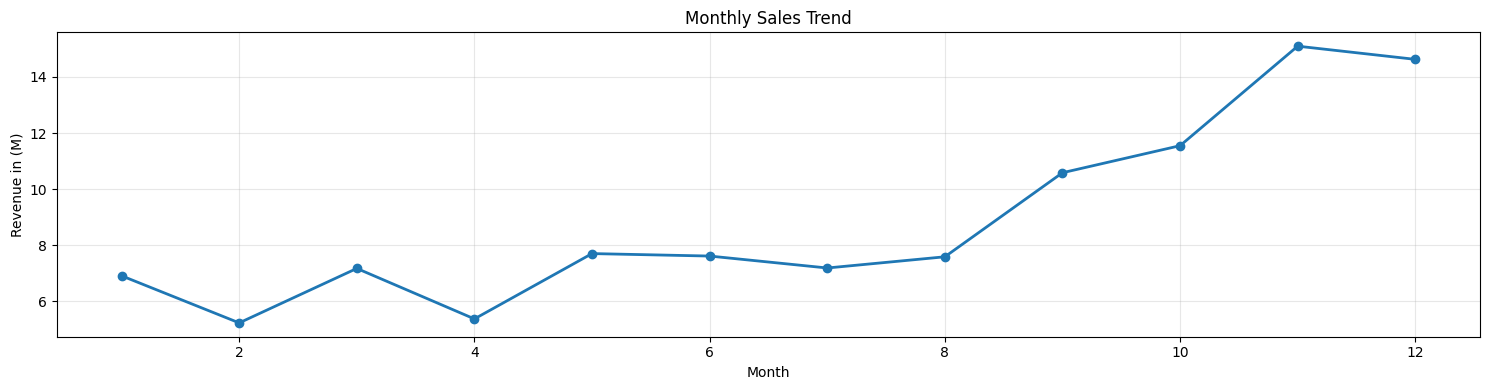

In [ ]:
# 7. Monthly Sales Trend

plt.figure(figsize=(15,4))

sales_mont.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue in (M)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 8. Business Metrics
uniq_prod = (
    Ecomm_df.groupby('Description')['Revenue']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
# unique stock codes
uniq_Stck = Ecomm_df['StockCode'].unique()
# unique customers
uniq_CusID = Ecomm_df['CustomerID'].unique()
# country revenue
uniq_country = (
    Ecomm_df.groupby('Country')['Revenue']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
# top selling products
top10_quant = (
    Ecomm_df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
# lowest selling products
low10_quant = (
    Ecomm_df.groupby('Description')['Quantity']
    .sum()
    .sort_values()
    .head(10)
)
# top customers
top10_customer = (
    Ecomm_df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("Number of Unique Products :", Ecomm_df['Description'].nunique())
print("Number of Unique StockCode :", Ecomm_df['StockCode'].nunique())
print("Number of Unique CustomerID :", Ecomm_df['CustomerID'].nunique())
print("Number of Unique Country :", Ecomm_df['Country'].nunique())

Number of Unique Products : 4026
Number of Unique StockCode : 3922
Number of Unique CustomerID : 4338
Number of Unique Country : 38


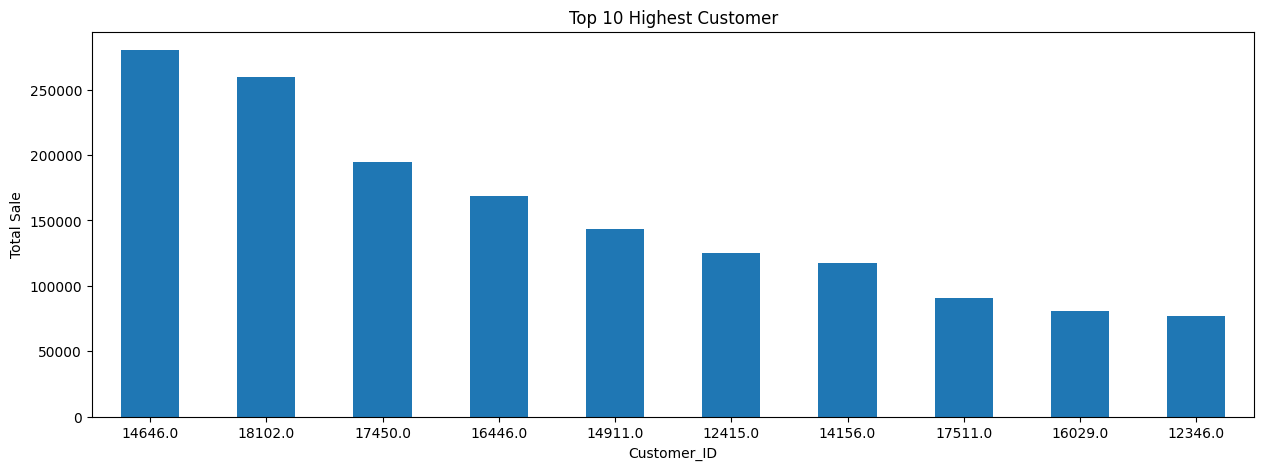

In [ ]:
# 9. Top Customers

top10_customer.plot(kind='bar', figsize=(15,5))

plt.xticks(rotation=0)
plt.title("Top 10 Highest Customer")
plt.xlabel("Customer_ID")
plt.ylabel("Total Sale")

plt.show()

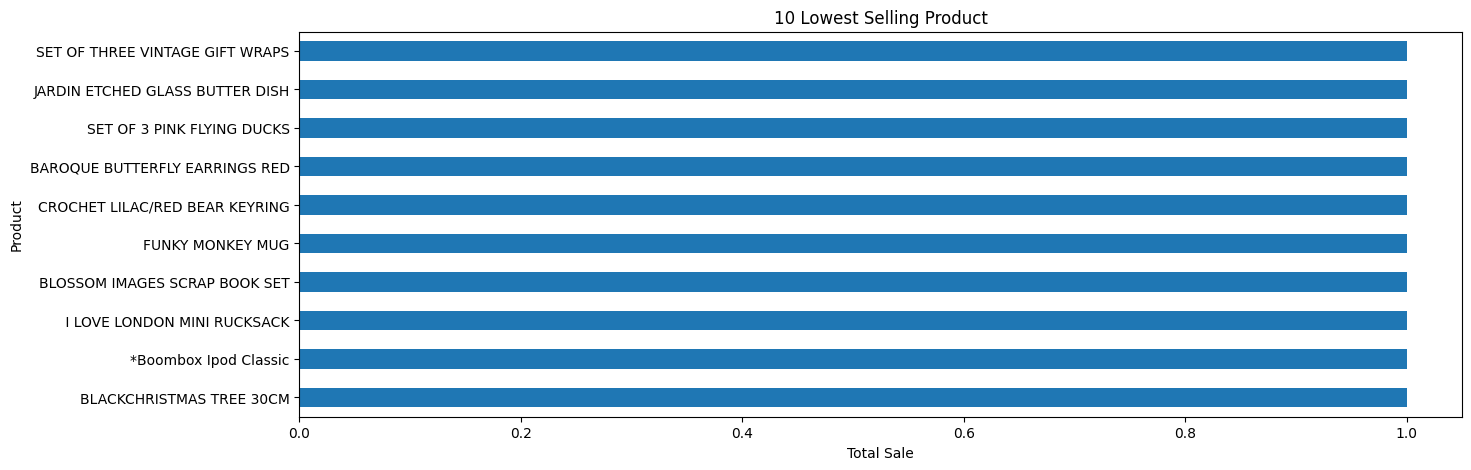

In [ ]:
# 10. Lowest Selling Products

low10_quant.plot(kind='barh', figsize=(15,5))

plt.title("10 Lowest Selling Product")
plt.xlabel("Total Sale")
plt.ylabel("Product")

plt.show()

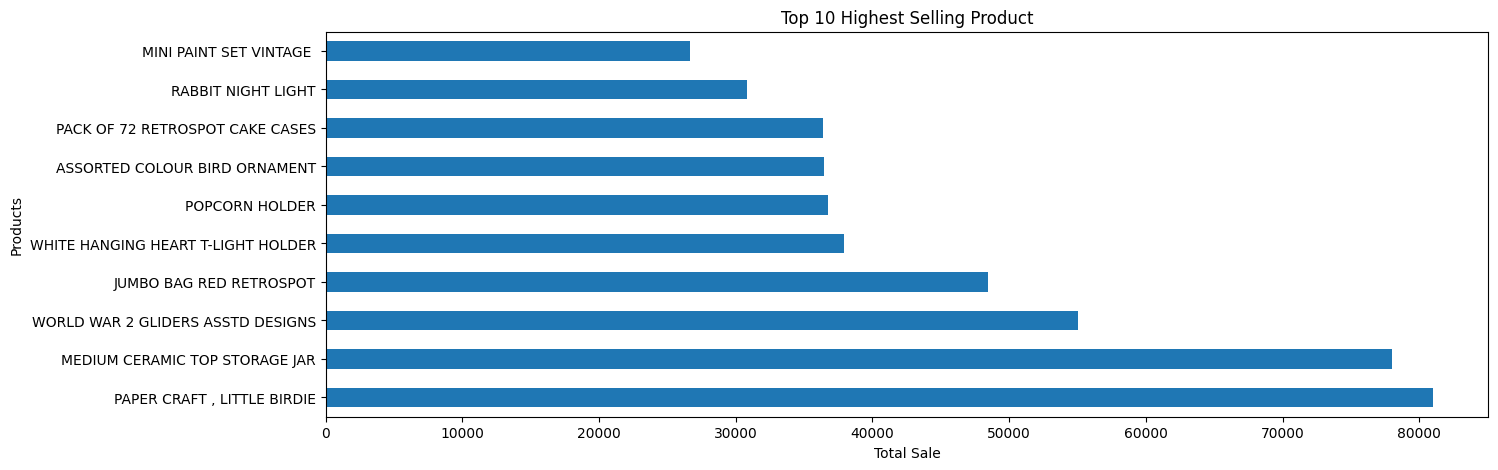

In [ ]:
# 11. Top Selling Products

top10_quant.plot(kind='barh', figsize=(15,5))

plt.title("Top 10 Highest Selling Product")
plt.xlabel("Total Sale")
plt.ylabel("Products")

plt.show()

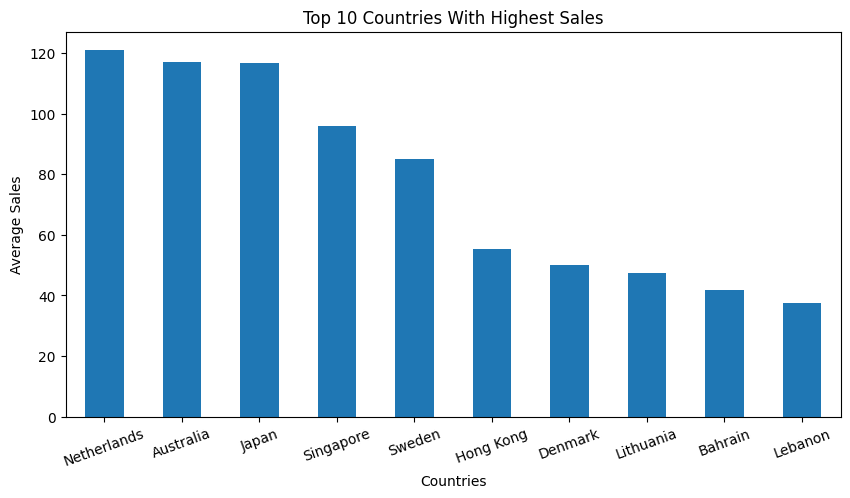

In [ ]:
# 12. Country Sales

uniq_country.plot(kind='bar', figsize=(10,5))

plt.xticks(rotation=20)
plt.title("Top 10 Countries With Highest Sales")
plt.xlabel("Countries")
plt.ylabel("Average Sales")

plt.show()

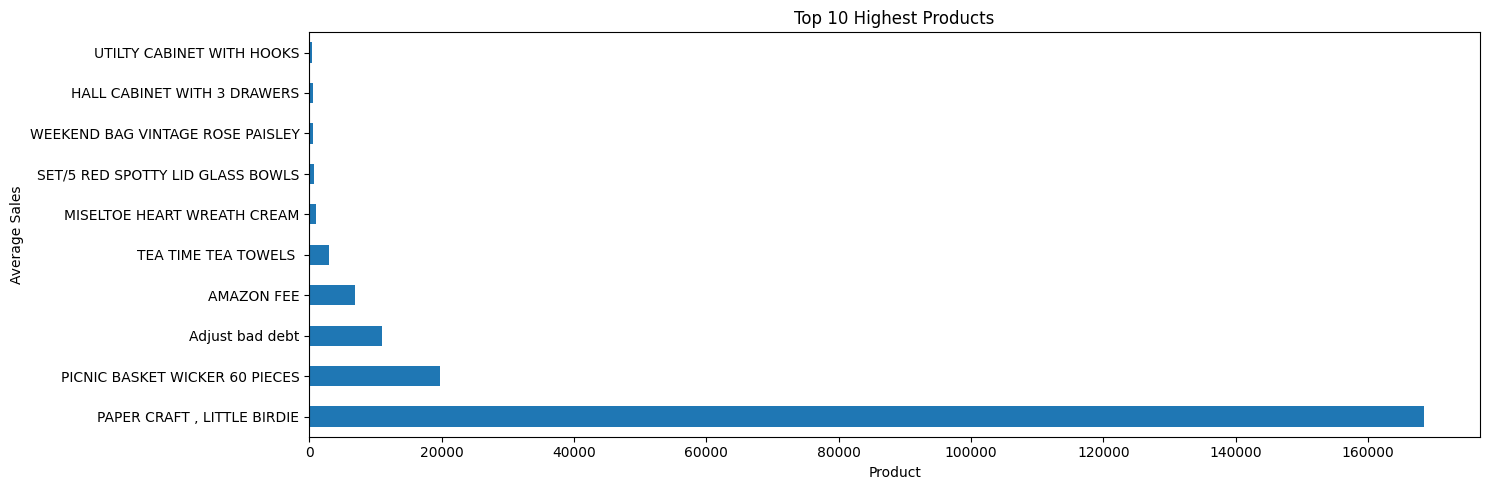

In [21]:
# 13. Product Revenue

uniq_prod.plot(kind='barh', figsize=(15,5))

plt.title("Top 10 Highest Products")
plt.xlabel("Product")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()
